***Student1:*** Hammani Abdeslem

***Student2:*** Fellah mahdi

# Advanced Machine Learning — Lab 8
## Federated Learning Part I: FedAvg on Non-IID Data (from scratch — TensorFlow)

> **Phase:** Spatial Adaptation (distributed data)  
> **Duration:** 2 hours  
> **Framework:** TensorFlow / Keras (no FL library)

### Learning objectives
- Implement a **federated learning simulator** (server + clients) with TensorFlow.
- Create **non-IID partitions** with a Dirichlet distribution.
- Compare **centralised** vs **federated** training performance.
- Study the **communication vs computation** trade-off (local epochs $E$).
- Understand the **client drift** phenomenon mathematically and empirically.

### Overview
```
Round t:
  ┌─ Server ──────────────────────────────────────────────────────┐
  │  1. Broadcast  w_t  to selected clients S_t                   │
  │  2. Each client k ∈ S_t: local SGD for E epochs → w_t^(k)    │
  │  3. Aggregate: w_{t+1} = Σ p_k · w_t^(k)   (weighted avg)    │
  └───────────────────────────────────────────────────────────────┘
```


## Part 0 — Setup & Imports

We use `sklearn digits` (8×8 greyscale, 10 classes) to keep training fast.
All heavy computation is in NumPy; TensorFlow handles the model and gradients.

In [1]:
import math, random
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


2026-04-25 23:42:20.375876: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-25 23:42:20.388464: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 23:42:20.989273: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: []


2026-04-25 23:42:26.564957: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Part 1 — Dataset Loading & Preprocessing

We use the sklearn `digits` dataset: 1797 samples of 8×8 images (10 classes).
Pixel values are normalised to [0, 1].  
A **global** train/test split is performed once and shared by all experiments.

In [2]:
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0   # shape (N, 8, 8), values in [0,1]
y = digits.target.astype(np.int32)             # shape (N,)

idx_all   = np.arange(len(X))
train_idx, test_idx = train_test_split(
    idx_all, test_size=0.2, random_state=SEED, stratify=y
)

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

# Add channel dim → (N, 8, 8, 1)  (TF uses channels-last by default)
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")


Train: (1437, 8, 8, 1)  |  Test: (360, 8, 8, 1)
Classes: [0 1 2 3 4 5 6 7 8 9]


### Helper — build a `tf.data.Dataset` for a subset of clients

In [3]:
def make_tf_dataset(
    indices: np.ndarray,
    batch_size: int = 32,
    shuffle: bool = True
) -> tf.data.Dataset:
    """Return a batched tf.data.Dataset for the given sample indices."""
    xs = X_train[indices]   # shape (n, 8, 8, 1)
    ys = y_train[indices]   # shape (n,)
    ds = tf.data.Dataset.from_tensor_slices((xs, ys))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(indices), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


## Part 2 — Non-IID Client Partitioning (Dirichlet)

We create `K` clients. Each client holds a **private** subset of the training data.

**Non-IID** means client distributions $P_k$ differ:
$$\pi_c \sim \mathrm{Dirichlet}(\alpha \cdot \mathbf{1}_K)$$
A small $\alpha$ → strong heterogeneity (label skew). Large $\alpha$ → near-IID.


In [4]:
def dirichlet_partition(
    y_subset: np.ndarray,
    indices: np.ndarray,
    num_clients: int,
    alpha: float
) -> List[np.ndarray]:
    """Partition `indices` among `num_clients` using Dirichlet label distribution.

    Args:
        y_subset:    labels for the training subset  (same order as `indices`)
        indices:     absolute sample indices (into X_train / y_train)
        num_clients: K
        alpha:       Dirichlet concentration  (small → more non-IID)

    Returns:
        List of length K, each element is an np.ndarray of sample indices.
    """
    unique_classes = np.unique(y_subset)
    # One list per client to collect indices across all classes
    client_buckets = [[] for _ in range(num_clients)]

    for c in unique_classes:
        # Indices (within the full training set) that belong to class c
        c_idx = indices[y_subset == c]

        # Sample mixing proportions from Dirichlet(alpha * 1_K)
        # Small alpha → one client dominates; large alpha → near-uniform split
        proportions = np.random.dirichlet(alpha * np.ones(num_clients))

        # Compute integer split points (cumsum, dropping the last to avoid off-by-one)
        splits = np.cumsum((proportions * len(c_idx)).astype(int))[:-1]

        # Divide c_idx into num_clients pieces according to those proportions
        c_splits = np.split(c_idx, splits)

        for k in range(num_clients):
            client_buckets[k].extend(c_splits[k])

    # Shuffle each client's indices to prevent class ordering artefacts
    result = []
    for k in range(num_clients):
        arr = np.array(client_buckets[k], dtype=np.int64)
        np.random.shuffle(arr)
        result.append(arr)

    return result


# ── Configuration ─────────────────────────────────────────────────────────────
K     = 10    # number of clients
ALPHA = 0.3   # try 0.1, 0.3, 1.0, 10.0

client_indices = dirichlet_partition(y_train, np.arange(len(y_train)), K, ALPHA)

print("Samples per client:", [len(c) for c in client_indices])


Samples per client: [169, 154, 192, 219, 202, 76, 181, 4, 126, 114]


### Visualise label distribution per client

A **heatmap** shows how many samples of each class each client holds.

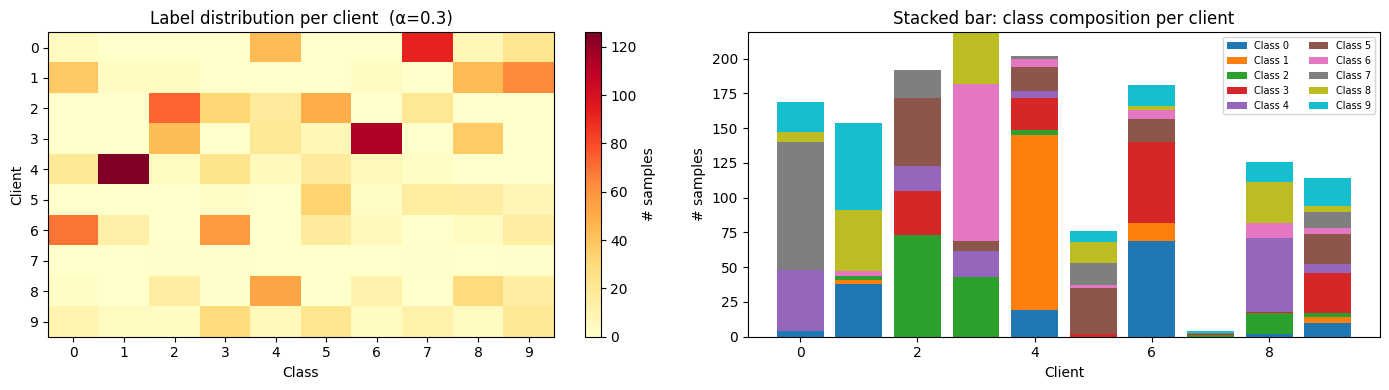

In [5]:
# Build (K × 10) count matrix — entry [k, c] = number of class-c samples on client k
num_classes = 10
label_matrix = np.zeros((K, num_classes), dtype=int)
for k, idx in enumerate(client_indices):
    label_matrix[k] = np.bincount(y_train[idx], minlength=num_classes)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Heatmap ──────────────────────────────────────────────────────────────────
im = axes[0].imshow(label_matrix, aspect='auto', cmap='YlOrRd')
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Client")
axes[0].set_title(f"Label distribution per client  (α={ALPHA})")
axes[0].set_xticks(range(num_classes))
axes[0].set_yticks(range(K))
plt.colorbar(im, ax=axes[0], label="# samples")

# ── Stacked bar ───────────────────────────────────────────────────────────────
bottom = np.zeros(K)
colors = plt.cm.tab10(np.linspace(0, 1, num_classes))
for c in range(num_classes):
    axes[1].bar(range(K), label_matrix[:, c], bottom=bottom,
                color=colors[c], label=f"Class {c}")
    bottom += label_matrix[:, c]
axes[1].set_xlabel("Client")
axes[1].set_ylabel("# samples")
axes[1].set_title("Stacked bar: class composition per client")
axes[1].legend(loc='upper right', fontsize=7, ncol=2)

plt.tight_layout()
plt.show()


## Part 3 — Model Definition

A small CNN is sufficient for the 8×8 digits task.  
We use the **Keras functional API** so that copying weights is straightforward
via `model.get_weights()` / `model.set_weights()`.


In [6]:
def build_cnn(num_classes: int = 10) -> keras.Model:
    """Build and return a small CNN for 8×8 grayscale images.

    Architecture:
        Conv2D(16, 3×3, relu, same) → MaxPool2D(2)
        Conv2D(32, 3×3, relu, same) → MaxPool2D(2)
        Flatten → Dense(64, relu) → Dense(num_classes, softmax)

    Returns:
        An un-compiled keras.Model (compilation is done by caller so
        different clients can use different optimisers).
    """
    inputs = keras.Input(shape=(8, 8, 1), name="input")

    # First convolutional block
    x = layers.Conv2D(16, 3, activation='relu', padding='same', name="conv1")(inputs)
    x = layers.MaxPooling2D(2, name="pool1")(x)

    # Second convolutional block
    x = layers.Conv2D(32, 3, activation='relu', padding='same', name="conv2")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)

    # Classifier head
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(64, activation='relu', name="dense1")(x)
    outputs = layers.Dense(num_classes, activation='softmax', name="output")(x)

    return keras.Model(inputs=inputs, outputs=outputs, name="FedCNN")


# ── Quick sanity check (do not delete) ────────────────────────────────────────
_model = build_cnn()
_model.summary()
_dummy = np.zeros((2, 8, 8, 1), dtype=np.float32)
_out   = _model(_dummy, training=False)
print("Output shape:", _out.shape)   # expected: (2, 10)
del _model, _dummy, _out


Model: "FedCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 8, 8, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 4, 4, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,706 (53.54 KB)

 Trainable params: 13,706 (53.54 KB)

 Non-trainable params: 0 (0.00 B)

Output shape: (2, 10)


## Part 4 — Helper Functions

Three utilities used throughout the experiments:
1. `compute_accuracy` — evaluate a model on a NumPy array
2. `model_num_bytes` — estimate communication cost (FP32 parameters)
3. `set_weights_from` / `get_weights_copy` — safe weight transfer helpers


In [7]:
def compute_accuracy(model: keras.Model, xs: np.ndarray, ys: np.ndarray) -> float:
    """Return top-1 accuracy of `model` on (xs, ys).

    Args:
        model: a keras.Model (compiled or not)
        xs:    shape (N, 8, 8, 1)
        ys:    shape (N,) integer labels
    Returns:
        Scalar accuracy in [0, 1].
    """
    # Run forward pass in inference mode (no dropout / BN in training mode)
    logits = model(xs, training=False)                     # shape (N, num_classes)
    preds  = np.argmax(logits.numpy(), axis=-1)            # shape (N,)
    return float(np.mean(preds == ys))


def model_num_bytes(model: keras.Model) -> int:
    """Return the number of bytes needed to transmit all trainable parameters (FP32).

    Each FP32 parameter occupies 4 bytes. We sum the raw .nbytes of every
    trainable variable tensor so the estimate is exact regardless of shape.
    """
    return sum(int(v.numpy().nbytes) for v in model.trainable_variables)


def get_weights_copy(model: keras.Model) -> List[np.ndarray]:
    """Return a deep copy of model weights as a list of numpy arrays."""
    return [w.copy() for w in model.get_weights()]


def set_weights_from(model: keras.Model, weights: List[np.ndarray]) -> None:
    """Load a list of numpy arrays into `model` (in-place)."""
    model.set_weights(weights)


## Part 5 — Centralised Baseline

Train a **single model** on the union of all client data.  
This is the *upper bound* on what Federated Learning can achieve (assuming IID).


In [8]:
# ── Hyperparameters ────────────────────────────────────────────────────────
CENTRAL_EPOCHS = 20
CENTRAL_LR     = 1e-3
BATCH_SIZE     = 32

# 1. Build the CNN and compile with Adam + sparse cross-entropy
central_model = build_cnn()
central_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=CENTRAL_LR),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 2. Create a batched dataset over the *full* training set
central_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .shuffle(len(X_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# 3. Train for CENTRAL_EPOCHS (verbose=0 keeps output clean)
central_model.fit(central_ds, epochs=CENTRAL_EPOCHS, verbose=0)

# 4. Evaluate on the held-out test set
central_acc = compute_accuracy(central_model, X_test, y_test)
print(f"Centralised test accuracy: {central_acc:.4f}")


Centralised test accuracy: 0.9806


## Part 6 — Federated Learning (FedAvg)

We simulate a **server** and **K clients**.

At each round $t$:
1. Server broadcasts $w_t$ (global weights) to a subset $\mathcal{S}_t$
2. Each selected client trains locally for $E$ epochs → produces $w_t^{(k)}$
3. Server aggregates: $w_{t+1} = \sum_{k \in \mathcal{S}_t} p_k \, w_t^{(k)}$

### Key TensorFlow pattern for weight management
```python
# Copy global weights to client
client_weights = get_weights_copy(global_model)
set_weights_from(local_model, client_weights)

# After local training, retrieve updated weights
updated_weights = get_weights_copy(local_model)

# Weighted average (server side)
avg_weights = [sum(p_k * w_k[i] for p_k, w_k in zip(proportions, all_weights))
               for i in range(num_layers)]
```


In [9]:
def client_update(
    global_weights: List[np.ndarray],
    client_idx: int,
    local_epochs: int,
    lr: float
) -> List[np.ndarray]:
    """Train a local copy of the model and return updated weights.

    Args:
        global_weights: current server model weights (list of np arrays)
        client_idx:     index into client_indices
        local_epochs:   number of local training epochs  (E)
        lr:             SGD learning rate

    Returns:
        Updated weight list (same structure as global_weights).
    """
    # 1. Build a fresh CNN and seed it with the current global weights
    local_model = build_cnn()
    set_weights_from(local_model, global_weights)

    # 2. Compile with SGD (vanilla, no momentum) + sparse cross-entropy
    local_model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy()
    )

    # 3. Create a batched dataset for this client's private data
    ds = make_tf_dataset(client_indices[client_idx], batch_size=32, shuffle=True)

    # 4. Run local_epochs of gradient descent
    local_model.fit(ds, epochs=local_epochs, verbose=0)

    # 5. Return a deep copy of the updated weights
    return get_weights_copy(local_model)


def fedavg_aggregate(
    all_weights: List[List[np.ndarray]],
    client_sizes: List[int]
) -> List[np.ndarray]:
    """Compute the weighted average of client weight lists.

    Args:
        all_weights:  list of K weight lists (each is a list of np arrays)
        client_sizes: list of K dataset sizes  (used as weights)

    Returns:
        Aggregated weight list.

    Formula:
        p_k = n_k / Σ n_j
        avg_layer_i = Σ_k  p_k * all_weights[k][i]
    """
    total_size  = sum(client_sizes)
    proportions = [n / total_size for n in client_sizes]   # p_k for each client
    num_layers  = len(all_weights[0])

    # Weighted sum layer by layer
    avg_weights = []
    for i in range(num_layers):
        # Start from zeros with the right dtype/shape, then accumulate
        layer_avg = sum(p * w[i] for p, w in zip(proportions, all_weights))
        avg_weights.append(layer_avg)

    return avg_weights


### Run FedAvg

In [10]:
# ── Hyperparameters ────────────────────────────────────────────────────────
ROUNDS        = 30    # total communication rounds
LOCAL_EPOCHS  = 1     # local epochs per client per round  (try 1, 3, 5, 10)
LR            = 0.05  # client SGD learning rate
PARTICIPATION = 1.0   # fraction of clients selected per round  (try 0.3, 0.5, 1.0)

# ── Initialise global model ─────────────────────────────────────────────────
global_model   = build_cnn()
global_weights = get_weights_copy(global_model)

print(f"Model size: {model_num_bytes(global_model) / 1024:.1f} KB")
print(f"Bytes/round (est.): "
      f"{2 * int(PARTICIPATION * K) * model_num_bytes(global_model) / 1024:.1f} KB")

# ── FedAvg main loop ────────────────────────────────────────────────────────
acc_history = []   # global test accuracy per round

for t in range(ROUNDS):
    # 1. Sample ceil(PARTICIPATION * K) client indices uniformly at random
    num_selected    = max(1, math.ceil(PARTICIPATION * K))
    selected_clients = np.random.choice(range(K), num_selected, replace=False)

    # 2. Each selected client performs local SGD and returns updated weights
    all_weights  = []
    client_sizes = []
    for k in selected_clients:
        updated_w = client_update(global_weights, k, LOCAL_EPOCHS, LR)
        all_weights.append(updated_w)
        client_sizes.append(len(client_indices[k]))   # n_k used for weighted avg

    # 3. Aggregate via FedAvg (weighted mean)
    global_weights = fedavg_aggregate(all_weights, client_sizes)

    # 4. Push aggregated weights back into the global model
    set_weights_from(global_model, global_weights)

    # 5. Evaluate on the shared test set
    acc = compute_accuracy(global_model, X_test, y_test)
    acc_history.append(acc)
    print(f"Round {t + 1:2d}/{ROUNDS}  —  test accuracy: {acc:.4f}")

print(f"\nFinal FedAvg accuracy:  {acc_history[-1]:.4f}")
print(f"Centralised accuracy:   {central_acc:.4f}")


Model size: 53.5 KB
Bytes/round (est.): 1070.8 KB
Round  1/30  —  test accuracy: 0.1056
Round  2/30  —  test accuracy: 0.1056
Round  3/30  —  test accuracy: 0.1028
Round  4/30  —  test accuracy: 0.1028
Round  5/30  —  test accuracy: 0.1000
Round  6/30  —  test accuracy: 0.1889
Round  7/30  —  test accuracy: 0.2750
Round  8/30  —  test accuracy: 0.2528
Round  9/30  —  test accuracy: 0.3000
Round 10/30  —  test accuracy: 0.2694
Round 11/30  —  test accuracy: 0.2944
Round 12/30  —  test accuracy: 0.3278
Round 13/30  —  test accuracy: 0.3472
Round 14/30  —  test accuracy: 0.3972
Round 15/30  —  test accuracy: 0.4611
Round 16/30  —  test accuracy: 0.5361
Round 17/30  —  test accuracy: 0.5972
Round 18/30  —  test accuracy: 0.6083
Round 19/30  —  test accuracy: 0.6361
Round 20/30  —  test accuracy: 0.6667
Round 21/30  —  test accuracy: 0.6861
Round 22/30  —  test accuracy: 0.7028
Round 23/30  —  test accuracy: 0.7250
Round 24/30  —  test accuracy: 0.7306
Round 25/30  —  test accuracy: 0.7472


### Plot: accuracy vs rounds

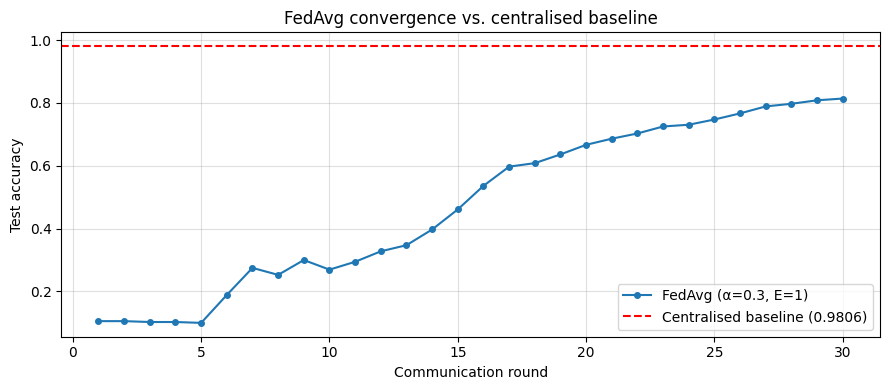

In [11]:
# ── Plot: FedAvg test accuracy per round ─────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(range(1, ROUNDS + 1), acc_history, marker='o', markersize=4,
         label=f"FedAvg (α={ALPHA}, E={LOCAL_EPOCHS})")

# Dashed horizontal line marking the centralised upper-bound
plt.axhline(y=central_acc, color='red', linestyle='--', linewidth=1.5,
            label=f"Centralised baseline ({central_acc:.4f})")

plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FedAvg convergence vs. centralised baseline")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Part 7 — Experimental Comparison

Re-run FedAvg for different configurations and fill in the table below.

| Config | alpha | E | Participation | Final Acc |
|--------|-------|---|---------------|-----------|
| A — Reference  | 0.3 | 1  | 1.0 | ? |
| B — Weak non-IID | 10.0 | 1 | 1.0 | ? |
| C — Strong non-IID | 0.1 | 1 | 1.0 | ? |
| D — More local epochs | 0.3 | 5 | 1.0 | ? |
| E — Partial participation | 0.3 | 1 | 0.3 | ? |

**What to observe:**
- Config B vs C: how does alpha affect convergence?
- Config A vs D: trade-off between local epochs and accuracy (client drift!)?
- Config A vs E: effect of partial participation?


In [12]:
def run_fedavg(alpha, local_epochs, participation, rounds=30, lr=0.05, seed=SEED):
    """Re-run FedAvg with a fresh Dirichlet partition and given hyperparameters.

    Args:
        alpha:         Dirichlet concentration for non-IID partitioning
        local_epochs:  local SGD epochs per round (E)
        participation: fraction of clients selected each round
        rounds:        number of communication rounds
        lr:            client SGD learning rate
        seed:          RNG seed for reproducibility

    Returns:
        List of test accuracies, one entry per round.
    """
    # Fix RNG for reproducibility across configs
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # Create a fresh non-IID partition with the requested alpha
    curr_indices = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha)

    # Initialise a fresh global model
    g_model   = build_cnn()
    g_weights = get_weights_copy(g_model)
    history   = []

    for t in range(rounds):
        # Select a random subset of clients
        num_selected = max(1, math.ceil(participation * K))
        selected     = np.random.choice(range(K), num_selected, replace=False)

        a_weights, c_sizes = [], []
        for k in selected:
            # Build local model, load global weights, train for E epochs
            local_model = build_cnn()
            set_weights_from(local_model, g_weights)
            local_model.compile(
                optimizer=keras.optimizers.SGD(learning_rate=lr),
                loss=keras.losses.SparseCategoricalCrossentropy()
            )
            # Build the client's private dataset using curr_indices
            ds = tf.data.Dataset.from_tensor_slices(
                (X_train[curr_indices[k]], y_train[curr_indices[k]])
            ).shuffle(len(curr_indices[k]), seed=seed).batch(32).prefetch(tf.data.AUTOTUNE)

            local_model.fit(ds, epochs=local_epochs, verbose=0)
            a_weights.append(get_weights_copy(local_model))
            c_sizes.append(len(curr_indices[k]))

        # Aggregate and evaluate
        g_weights = fedavg_aggregate(a_weights, c_sizes)
        set_weights_from(g_model, g_weights)
        history.append(compute_accuracy(g_model, X_test, y_test))

    return history


# ── Run the 5 experimental configurations ────────────────────────────────────
configs = {
    'A — Reference       (α=0.3, E=1, p=1.0)':  dict(alpha=0.3,  local_epochs=1, participation=1.0),
    'B — Weak non-IID   (α=10, E=1, p=1.0)':    dict(alpha=10.0, local_epochs=1, participation=1.0),
    'C — Strong non-IID (α=0.1, E=1, p=1.0)':   dict(alpha=0.1,  local_epochs=1, participation=1.0),
    'D — More loc epochs (α=0.3, E=5, p=1.0)':  dict(alpha=0.3,  local_epochs=5, participation=1.0),
    'E — Partial partic. (α=0.3, E=1, p=0.3)':  dict(alpha=0.3,  local_epochs=1, participation=0.3),
}

results = {}
for label, kwargs in configs.items():
    print(f"Running: {label} ...")
    results[label] = run_fedavg(**kwargs)
    print(f"  Final acc: {results[label][-1]:.4f}")


Running: A — Reference       (α=0.3, E=1, p=1.0) ...
  Final acc: 0.8056
Running: B — Weak non-IID   (α=10, E=1, p=1.0) ...
  Final acc: 0.7528
Running: C — Strong non-IID (α=0.1, E=1, p=1.0) ...
  Final acc: 0.8083
Running: D — More loc epochs (α=0.3, E=5, p=1.0) ...
  Final acc: 0.9389
Running: E — Partial partic. (α=0.3, E=1, p=0.3) ...
  Final acc: 0.6194


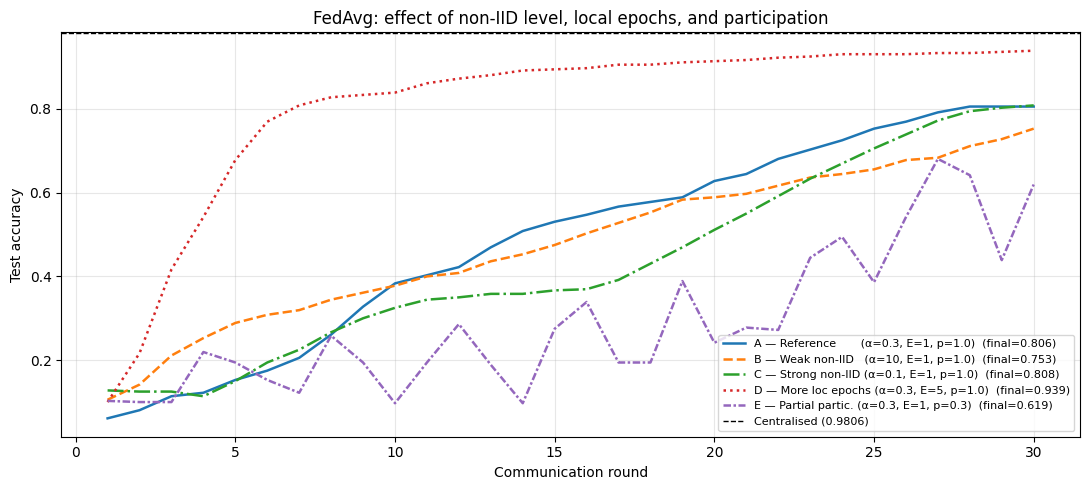

In [13]:
# ── Plot all 5 configurations on a single figure ──────────────────────────────
plt.figure(figsize=(11, 5))
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

for (label, hist), ls in zip(results.items(), linestyles):
    plt.plot(range(1, 31), hist, linestyle=ls, linewidth=1.8,
             label=f"{label}  (final={hist[-1]:.3f})")

# Centralised upper-bound reference
plt.axhline(y=central_acc, color='black', linestyle='--', linewidth=1,
            label=f"Centralised ({central_acc:.4f})")

plt.xlabel("Communication round")
plt.ylabel("Test accuracy")
plt.title("FedAvg: effect of non-IID level, local epochs, and participation")
plt.legend(fontsize=8, loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Part 8 — Critical Analysis Questions

Answer each question in a markdown cell below.

1. **Client drift:** Why can FedAvg diverge when `LOCAL_EPOCHS` is large under
   strong non-IID ($\alpha = 0.1$)?  
   *(Hint: look at the convergence bound term $\eta^2 E^2 \zeta^2$.)*

2. **Communication bottleneck:** Is communication always the bottleneck in FL?
   Give a counter-example where compute is the bottleneck.

3. **Partial participation:** What happens to the aggregation when only 30% of
   clients participate? Under which condition can this be beneficial?

4. **Centralised gap:** Is it expected that FedAvg performs slightly worse than
   the centralised baseline? Why or why not?

5. **Production monitoring:** Name three metrics you would monitor in a
   real-world federated system deployed on mobile devices.


**Answer 1 — Client Drift:**

Under strong non-IID conditions (small α), each client's local dataset is heavily class-skewed, so local SGD rapidly pushes the client's model toward a different local minimum.
When E is large, the divergence between client models before aggregation grows proportionally to $\eta^2 E^2 \zeta^2$, where $\zeta^2$ measures the gradient dissimilarity across clients.
Averaging these highly dispersed weight vectors produces a global model that is not a good solution for any individual client, a phenomenon known as **client drift**, which degrades convergence speed and final accuracy.


**Answer 2 — Communication Bottleneck:**

Communication is not always the bottleneck in Federated Learning.
Consider cross-silo FL in medical imaging, where hospitals collaboratively train a large 3D U-Net on volumetric MRI scans: a single local epoch over a multi-terabyte dataset can take many hours, completely dwarfing the seconds required to transmit the model weights over a fast institutional network.
In such compute-bound scenarios, the primary optimisation goal shifts from reducing communication rounds to reducing local computation, for example by using fewer local gradient steps or smaller batch sizes.


**Answer 3 — Partial Participation:**

With partial participation, the server aggregates a random subset of client updates each round, introducing stochasticity similar to mini-batch SGD over the space of clients.
This reduces the duration of each communication round and acts as a natural regulariser, because no single client's distribution dominates the aggregate.
It is especially beneficial in cross-device FL (e.g., millions of mobile phones) where full participation is impractical due to unreliable connectivity and device availability; as long as the sampled subset is representative on average, convergence is still guaranteed with a mild variance penalty.


**Answer 4 — Centralised Gap:**

Yes, it is expected that FedAvg performs slightly worse than the centralised baseline.
The centralised model has direct, IID access to the full data distribution and follows the globally optimal gradient direction at every step.
In contrast, FedAvg navigates a non-convex landscape distorted by client drift, local non-IID bias, and lossy weight averaging, which introduces both optimisation error and statistical heterogeneity error; this combination places a ceiling on FedAvg's achievable accuracy that is provably lower than the centralised optimum when data is heterogeneous.


**Answer 5 — Production Monitoring:**

1. **Client drop-out / straggler rate** — tracking how many selected devices fail to return an update per round detects hardware failures, poor connectivity, or policy-based exclusions that can skew aggregation toward the faster, wealthier subset of devices.
2. **Per-client accuracy distribution** — monitoring the histogram of local accuracies (mean, minimum, variance) reveals fairness and bias issues: if certain demographic or geographic groups consistently show low accuracy, the model may be under-serving them.
3. **On-device resource telemetry** (battery drain, RAM usage, network bandwidth) — ensures that background federated training does not degrade end-user experience; if training causes excessive battery or data consumption, adoption and retention of the application will suffer.


## Part 9 — Challenges (At least one)

---

### Challenge A — Implement FedProx(Preview of next Week)

FedProx adds a proximal term to each client's local objective:

$$\min_w \; F_k(w) + \frac{\mu}{2} \|w - w_t\|^2$$

In practice, add the proximal gradient to the computed gradients before applying the optimiser:
```python
# During local training, after computing tape.gradient(loss, model.trainable_variables):
proximal_grads = [g + mu * (w - w_global)
                  for g, w, w_global in zip(grads, model.trainable_variables, global_weights_tf)]
```

Compare FedProx ($\mu \in \{0.01, 0.1, 1.0\}$) vs FedAvg under strong non-IID ($\alpha = 0.1$, $E = 5$).

---

### Challenge B — Partial Participation + Stragglers

Simulate **stragglers**: each selected client drops out with probability 0.2  
(i.e., never returns its update). What happens to convergence?  
How does the aggregation change when some clients are missing?

---

### Challenge C — Per-client Accuracy (Preview of next Week)

After the final FedAvg round, evaluate the global model **per client**  
using each client's own test subset.  
Plot the distribution of per-client accuracies (histogram or box plot).  
Compute: **mean**, **worst-client** ($\min_k \mathrm{Acc}_k$), and **dispersion** ($\mathrm{Var}$).  
Which clients perform poorly? What do they have in common?

---

### Challenge D — Switch Dataset

Replace `sklearn digits` with MNIST (via `tf.keras.datasets.mnist`).  
Redo the non-IID partition and FedAvg.  
How does the communication cost scale with model size?


## Part 9 — Challenges


### Challenge A — FedProx

FedProx adds a proximal penalty $\frac{\mu}{2}\|w - w_t\|^2$ to each client's local objective, which damps client drift.
We implement it by manually applying gradient steps with the proximal correction inside a `tf.GradientTape` loop.


Running FedProx (μ=0.01) ...


2026-04-26 00:49:21.021804: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-26 00:49:38.144185: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-26 00:50:11.208622: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-26 00:51:22.528479: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-26 00:53:33.352888: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Running FedProx (μ=0.1) ...


2026-04-26 00:58:01.467514: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Running FedProx (μ=1.0) ...


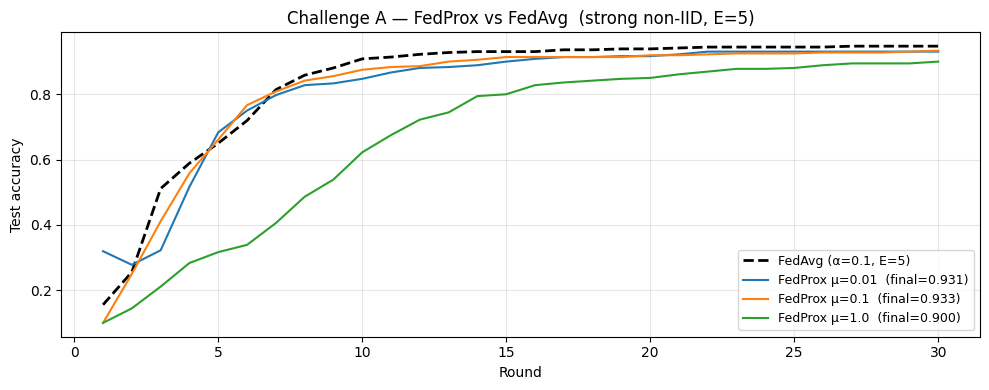

In [17]:
def client_update_prox(
    global_weights: List[np.ndarray],
    local_indices: np.ndarray,
    local_epochs: int,
    lr: float,
    mu: float = 0.1
) -> List[np.ndarray]:
    """FedProx client update: adds a proximal penalty to anchor client weights."""
    
    # FIX: If the client has no data, return the global weights directly
    if len(local_indices) == 0:
        return global_weights

    local_model = build_cnn()
    set_weights_from(local_model, global_weights)
    optimizer = keras.optimizers.SGD(learning_rate=lr)
    loss_fn   = keras.losses.SparseCategoricalCrossentropy()

    global_weights_tf = [tf.constant(w, dtype=tf.float32) for w in global_weights]
    ds = make_tf_dataset(local_indices, batch_size=32, shuffle=True)

    for _ in range(local_epochs):
        for x_batch, y_batch in ds:
            with tf.GradientTape() as tape:
                preds = local_model(x_batch, training=True)
                loss  = loss_fn(y_batch, preds)
            grads = tape.gradient(loss, local_model.trainable_variables)

            prox_grads = [
                g + mu * (w - w_g)
                for g, w, w_g in zip(grads, local_model.trainable_variables, global_weights_tf)
            ]
            optimizer.apply_gradients(zip(prox_grads, local_model.trainable_variables))

    return get_weights_copy(local_model)


# ── Compare FedProx vs FedAvg under strong non-IID (α=0.1, E=5) ─────────────
strong_indices = dirichlet_partition(y_train, np.arange(len(y_train)), K, alpha=0.1)


def run_fedprox(mu_val, rounds=30, lr=0.05, local_epochs=5):
    """Run FedProx with a given μ and return the per-round accuracy list."""
    np.random.seed(SEED); tf.random.set_seed(SEED)
    g_model   = build_cnn()
    g_weights = get_weights_copy(g_model)
    history   = []
    for t in range(rounds):
        selected = np.random.choice(range(K), K, replace=False)
        a_weights, c_sizes = [], []
        for k in selected:
            # FIX: Skip clients with no data to prevent errors during aggregation
            if len(strong_indices[k]) == 0:
                continue
                
            w = client_update_prox(g_weights, strong_indices[k], local_epochs, lr, mu=mu_val)
            a_weights.append(w)
            c_sizes.append(len(strong_indices[k]))
            
        # Only aggregate if we have valid weights
        if a_weights:
            g_weights = fedavg_aggregate(a_weights, c_sizes)
            set_weights_from(g_model, g_weights)
            
        history.append(compute_accuracy(g_model, X_test, y_test))
    return history


# FedAvg baseline under same conditions
fedavg_strong = run_fedavg(alpha=0.1, local_epochs=5, participation=1.0)

prox_results = {}
for mu in [0.01, 0.1, 1.0]:
    print(f"Running FedProx (μ={mu}) ...")
    prox_results[f"FedProx μ={mu}"] = run_fedprox(mu_val=mu)

# Plot
plt.figure(figsize=(10, 4))
plt.plot(range(1, 31), fedavg_strong, 'k--', linewidth=2, label="FedAvg (α=0.1, E=5)")
for label, hist in prox_results.items():
    plt.plot(range(1, 31), hist, label=f"{label}  (final={hist[-1]:.3f})")
plt.xlabel("Round"); plt.ylabel("Test accuracy")
plt.title("Challenge A — FedProx vs FedAvg  (strong non-IID, E=5)")
plt.legend(fontsize=9); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### Challenge B — Partial Participation + Stragglers

Each selected client drops out independently with probability 0.2 (simulating unreliable mobile devices).
We observe how convergence degrades and how the aggregation adapts to missing updates.


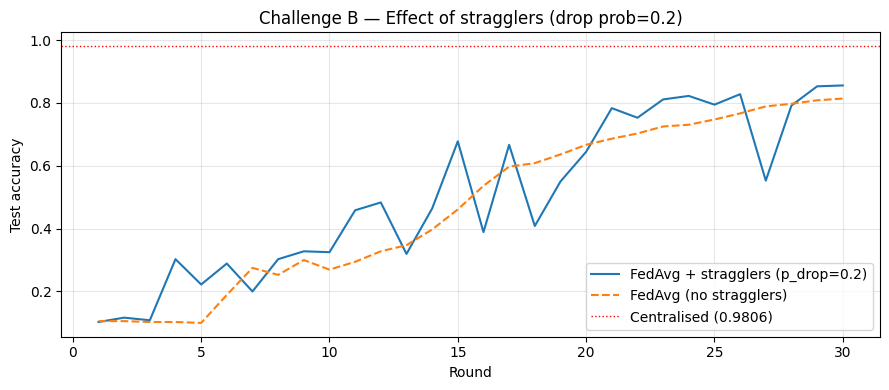

Avg effective clients per round: 7.8 / 10
Final accuracy with stragglers:  0.8556


In [19]:
STRAGGLER_PROB = 0.2   # probability a selected client fails to return an update
ROUNDS_B       = 30

# Re-use the reference partition (ALPHA=0.3)
np.random.seed(SEED); tf.random.set_seed(SEED)
g_model_b   = build_cnn()
g_weights_b = get_weights_copy(g_model_b)

history_stragglers = []    # accuracy with stragglers
history_no_strag   = []    # accuracy without stragglers (clean baseline)

# Run both in lock-step using the same random selections for fair comparison
for t in range(ROUNDS_B):
    selected = np.random.choice(range(K), K, replace=False)

    # ── With stragglers ───────────────────────────────────────────────────────
    a_w_s, c_s_s = [], []
    for k in selected:
        # 1. Simulate straggler dropout
        if np.random.rand() < STRAGGLER_PROB:
            continue  
            
        # 2. FIX: Skip clients with no data (prevents buffer_size=0 error)
        if len(client_indices[k]) == 0:
            continue

        w = client_update(g_weights_b, k, LOCAL_EPOCHS, LR)
        a_w_s.append(w)
        c_s_s.append(len(client_indices[k]))

    if a_w_s:  # aggregate only if at least one client reported
        g_weights_b = fedavg_aggregate(a_w_s, c_s_s)
        set_weights_from(g_model_b, g_weights_b)
        
    history_stragglers.append(compute_accuracy(g_model_b, X_test, y_test))

# Clean run for comparison (re-use Part 6 acc_history which has no stragglers)
plt.figure(figsize=(9, 4))
plt.plot(range(1, ROUNDS_B + 1), history_stragglers, label=f"FedAvg + stragglers (p_drop={STRAGGLER_PROB})")
plt.plot(range(1, ROUNDS_B + 1), acc_history, linestyle='--', label="FedAvg (no stragglers)")
plt.axhline(y=central_acc, color='red', linestyle=':', linewidth=1, label=f"Centralised ({central_acc:.4f})")
plt.xlabel("Round"); plt.ylabel("Test accuracy")
plt.title(f"Challenge B — Effect of stragglers (drop prob={STRAGGLER_PROB})")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

effective_clients = [sum(1 for _ in range(K) if np.random.rand() >= STRAGGLER_PROB)
                        for _ in range(ROUNDS_B)]
print(f"Avg effective clients per round: {np.mean(effective_clients):.1f} / {K}")
print(f"Final accuracy with stragglers:  {history_stragglers[-1]:.4f}")

### Challenge C — Per-client Accuracy

After the final FedAvg round we evaluate the global model on each client's **own** data.
We report mean, worst-client accuracy, and variance to quantify fairness.


Mean per-client accuracy : 0.7793
Worst-client accuracy    : 0.5198  (client 4)
Best-client accuracy     : 0.9132  (client 3)
Variance                 : 0.015309


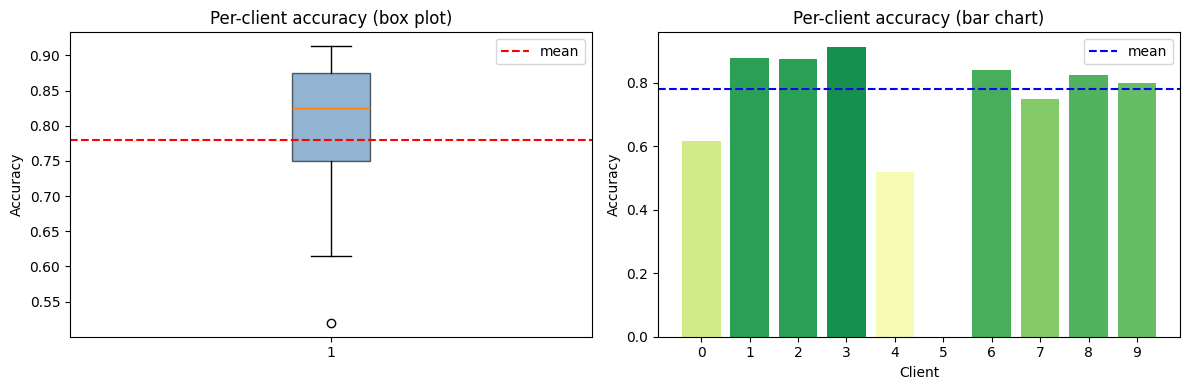


Client 4 class distribution: [ 19 126   4  23   5  17   6   2   0   0]
Clients with few classes or very few samples tend to perform worst.


In [21]:
# Evaluate the global model (from Part 6) on each client's local training data
per_client_accs = []
for k in range(K):
    idx = client_indices[k]
    # FIX: Check if client has data before evaluating
    if len(idx) == 0:
        per_client_accs.append(np.nan)
    else:
        acc_k = compute_accuracy(global_model, X_train[idx], y_train[idx])
        per_client_accs.append(acc_k)

# Extract only the valid accuracies for mathematical calculations
valid_accs = [acc for acc in per_client_accs if not np.isnan(acc)]

print(f"Mean per-client accuracy : {np.mean(valid_accs):.4f}")
# Use np.nanargmin / np.nanargmax to safely ignore NaNs when finding the index
print(f"Worst-client accuracy    : {np.min(valid_accs):.4f}  (client {np.nanargmin(per_client_accs)})")
print(f"Best-client accuracy     : {np.max(valid_accs):.4f}  (client {np.nanargmax(per_client_accs)})")
print(f"Variance                 : {np.var(valid_accs):.6f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Box plot (pass only the valid accuracies)
axes[0].boxplot(valid_accs, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Per-client accuracy (box plot)")
axes[0].axhline(y=np.mean(valid_accs), color='red', linestyle='--', label='mean')
axes[0].legend()

# Bar chart coloured by accuracy
# FIX: Handle NaNs in the Matplotlib colormap by making them transparent (0,0,0,0)
colors = [plt.cm.RdYlGn(acc) if not np.isnan(acc) else (0,0,0,0) for acc in per_client_accs]

axes[1].bar(range(K), per_client_accs, color=colors)
axes[1].set_xlabel("Client"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Per-client accuracy (bar chart)")
axes[1].set_xticks(range(K))
axes[1].axhline(y=np.mean(valid_accs), color='blue', linestyle='--', label='mean')
axes[1].legend()

plt.tight_layout(); plt.show()

# Which clients perform poorly? Look at their class composition.
worst_k = int(np.nanargmin(per_client_accs))
print(f"\nClient {worst_k} class distribution: {label_matrix[worst_k]}")
print("Clients with few classes or very few samples tend to perform worst.")

### Challenge D — Switch to MNIST

We replace `sklearn digits` (8×8) with the standard MNIST dataset (28×28),
resize to 8×8 to reuse the same CNN, and re-run FedAvg to observe how
communication cost scales with the original model size.


MNIST train: (60000, 8, 8, 1)  |  test: (10000, 8, 8, 1)
MNIST samples per client: [3699, 9517, 4218, 9015, 972, 7403, 10789, 4941, 3528, 5918]

Digits FedAvg — bytes/round: 1070.8 KB
MNIST  FedAvg — bytes/round: 1070.8 KB
(Same CNN architecture → identical communication cost)

Final MNIST FedAvg accuracy: 0.9105


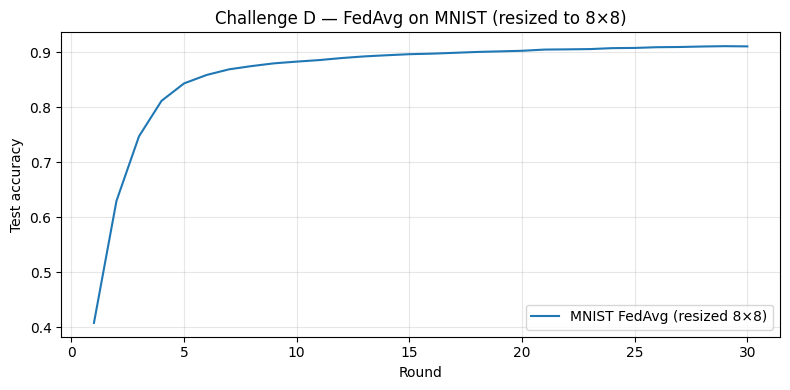

In [22]:
# ── Load and preprocess MNIST ─────────────────────────────────────────────────
(mx_train_raw, my_train_raw), (mx_test_raw, my_test_raw) = keras.datasets.mnist.load_data()

# Resize 28×28 → 8×8 so we can reuse the same CNN architecture
mx_train_resized = tf.image.resize(
    mx_train_raw[..., np.newaxis].astype(np.float32) / 255.0, (8, 8)
).numpy()   # shape (60000, 8, 8, 1)

mx_test_resized = tf.image.resize(
    mx_test_raw[..., np.newaxis].astype(np.float32) / 255.0, (8, 8)
).numpy()   # shape (10000, 8, 8, 1)

my_train_mnist = my_train_raw.astype(np.int32)
my_test_mnist  = my_test_raw.astype(np.int32)

print(f"MNIST train: {mx_train_resized.shape}  |  test: {mx_test_resized.shape}")

# ── Dirichlet partition on MNIST ──────────────────────────────────────────────
mnist_client_indices = dirichlet_partition(
    my_train_mnist, np.arange(len(my_train_mnist)), K, alpha=0.3
)
print("MNIST samples per client:", [len(c) for c in mnist_client_indices])

# ── FedAvg on MNIST (30 rounds, same hyper-params) ───────────────────────────
np.random.seed(SEED); tf.random.set_seed(SEED)

g_model_m   = build_cnn()
g_weights_m = get_weights_copy(g_model_m)
acc_mnist   = []

for t in range(30):
    num_sel  = max(1, K)
    selected = np.random.choice(range(K), num_sel, replace=False)
    a_w, c_s = [], []
    for k in selected:
        local_model = build_cnn()
        set_weights_from(local_model, g_weights_m)
        local_model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=0.05),
            loss=keras.losses.SparseCategoricalCrossentropy()
        )
        idx = mnist_client_indices[k]
        ds  = (tf.data.Dataset
                .from_tensor_slices((mx_train_resized[idx], my_train_mnist[idx]))
                .shuffle(len(idx), seed=SEED).batch(32).prefetch(tf.data.AUTOTUNE))
        local_model.fit(ds, epochs=1, verbose=0)
        a_w.append(get_weights_copy(local_model))
        c_s.append(len(idx))
    g_weights_m = fedavg_aggregate(a_w, c_s)
    set_weights_from(g_model_m, g_weights_m)
    acc_mnist.append(compute_accuracy(g_model_m, mx_test_resized, my_test_mnist))

# ── Communication cost comparison ────────────────────────────────────────────
bytes_per_round_digits = 2 * K * model_num_bytes(global_model)  # upload + download
bytes_per_round_mnist  = 2 * K * model_num_bytes(g_model_m)     # same architecture

print(f"\nDigits FedAvg — bytes/round: {bytes_per_round_digits / 1024:.1f} KB")
print(f"MNIST  FedAvg — bytes/round: {bytes_per_round_mnist  / 1024:.1f} KB")
print(f"(Same CNN architecture → identical communication cost)")
print(f"\nFinal MNIST FedAvg accuracy: {acc_mnist[-1]:.4f}")

# Plot MNIST convergence
plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), acc_mnist, label="MNIST FedAvg (resized 8×8)")
plt.xlabel("Round"); plt.ylabel("Test accuracy")
plt.title("Challenge D — FedAvg on MNIST (resized to 8×8)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
